# Bike Sharing Demand Prediction

Name: Pihu Chaudhary
Roll No: 2026UCA1899

Doing this for the AI/ML beginner task, picked Choice 1 (bike sharing) since it
looked easier to understand than the spotify one. Target is `count` - total bikes
rented in an hour, so this is a regression problem.

Im still pretty new to python/pandas (like a month in) so the code below is kept
simple, nothing fancy. Just going step by step - load data, look at it, clean it,
make graphs, prep for model, train all 5 models, compare.

## 1. Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
df = pd.read_csv('train.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.head()

            datetime  season  holiday  workingday  weather  temp   atemp  humidity  windspeed  casual  registered  count
0 2011-01-01 00:00:00       1        0           0        1  9.84  14.395        81        0.0       3          13     16
1 2011-01-01 01:00:00       1        0           0        1  9.02  13.635        80        0.0       8          32     40
2 2011-01-01 02:00:00       1        0           0        1  9.02  13.635        80        0.0       5          27     32
3 2011-01-01 03:00:00       1        0           0        1  9.84  14.395        75        0.0       3          10     13
4 2011-01-01 04:00:00       1        0           0        1  9.84  14.395        75        0.0       0           1      1

checking last 5 rows too just to make sure nothing weird at the end

In [3]:
df.tail()

                datetime  season  holiday  workingday  weather   temp   atemp  humidity  windspeed  casual  registered  count
10881 2012-12-19 19:00:00       4        0           1        1  15.58  19.695        50    26.0027       7         329    336
10882 2012-12-19 20:00:00       4        0           1        1  14.76  17.425        57    15.0013      10         231    241
10883 2012-12-19 21:00:00       4        0           1        1  13.94  15.910        61    15.0013       4         164    168
10884 2012-12-19 22:00:00       4        0           1        1  13.94  17.425        61     6.0032      12         117    129
10885 2012-12-19 23:00:00       4        0           1        1  13.12  16.665        66     8.9981       4          84     88

## 2. Basic inspection

In [4]:
print('rows, cols:', df.shape)

rows, cols: (10886, 12)

In [5]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [6]:
df.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [7]:
df.describe()

                        datetime        season       holiday    workingday       weather         temp         atemp      humidity     windspeed        casual    registered         count
count                      10886  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000  10886.000000  10886.000000  10886.000000  10886.000000  10886.000000  10886.000000
mean  2011-12-27 05:56:22.399412      2.506614      0.028569      0.680875      1.418427     20.23086     23.655084     61.886460     12.799395     36.021955    155.552177    191.574132
min          2011-01-01 00:00:00      1.000000      0.000000      0.000000      1.000000      0.82000      0.760000      0.000000      0.000000      0.000000      0.000000      1.000000
25%          2011-07-02 07:15:00      2.000000      0.000000      0.000000      1.000000     13.94000     16.665000     47.000000      7.001500      4.000000     36.000000     42.000000
50%          2012-01-01 20:30:00      3.000000      0.000000      1.00

from describe() -> mean of count is about 191 but median is only 145, mean is
bigger than median which usually means data is skewed to the right (a lot of low
values and then a few really high ones pulling the mean up). also 0 missing values
looks likely since count for every column is 10886, same as total rows.

## 3. Understanding the features

In [8]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

for c in cat_cols:
    print(c, '->', sorted(df[c].unique()))

season -> [1, 2, 3, 4]
holiday -> [0, 1]
workingday -> [0, 1]
weather -> [1, 2, 3, 4]

so season, holiday, workingday, weather are stored as numbers but theyre
actually categories (season 3 isnt "more" than season 1, its just a different
group). temp, atemp, humidity, windspeed, casual, registered are real continuous
numbers so those go in num_cols.

datetime is its own thing, a timestamp - not using it directly as a feature,
gonna pull hour/month/day out of it later.

## 4. Target variable

Going with `count` since thats literally what we're trying to predict (bikes
rented that hour). Its a number not a category so its regression.

Also noticed casual + registered probably = count, checking that below

In [9]:
check = (df['casual'] + df['registered'] == df['count']).all()
print('count always equals casual+registered:', check)

count always equals casual+registered: True

yep, exactly equal for every row. so casual and registered basically already
tell you the answer, cant use them as features or thats cheating. dropping both
later before training.

## 5. My observations so far

1. casual + registered = count exactly, so these 2 cant be used as features
2. datetime has hidden info (hour, month, day) that is probably gonna matter a lot,
   more useful than the raw timestamp
3. mean > median for count so its right-skewed, gonna check this with a graph later

## 6. Data Cleaning

### checking missing values

In [10]:
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

no missing values anywhere, nice, nothing to fill in here.

### checking duplicates

In [11]:
dupes = df.duplicated().sum()
print('duplicate rows:', dupes)

duplicate rows: 0

no dupes either, so this part is basically done, nothing to remove.

### checking for weird/invalid values

In [12]:
df[['temp','atemp','humidity','windspeed','casual','registered','count']].agg(['min','max']).T

             min       max
temp        0.82   41.0000
atemp       0.76   45.4550
humidity    0.00  100.0000
windspeed   0.00   56.9969
casual      0.00  367.0000
registered  0.00  886.0000
count       1.00  977.0000

everything looks fine here, humidity stays within 0-100 which makes sense
(its a %), nothing negative anywhere, temp/atemp look like normal celsius numbers.
also checked, theres one row where weather=4 (worst weather category) which is a
real value not an error, just a rare one, so keeping it as is. so basically no
cleaning needed besides what I already found (no missing/no dupes).

## 7. Visualizations

### Plot 1 - distribution of count (target variable)

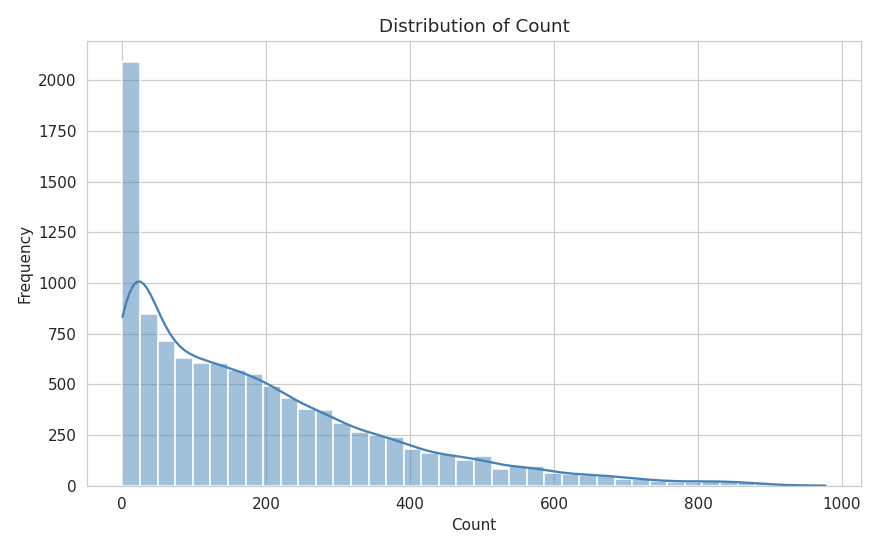

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['count'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Count')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

Observation: yeah, right skewed just like I guessed from describe() earlier.
most hours have a low count, then a long tail going up to almost 1000 for a few
hours (probably rush hour type stuff).

### Plot 2 - temp vs count

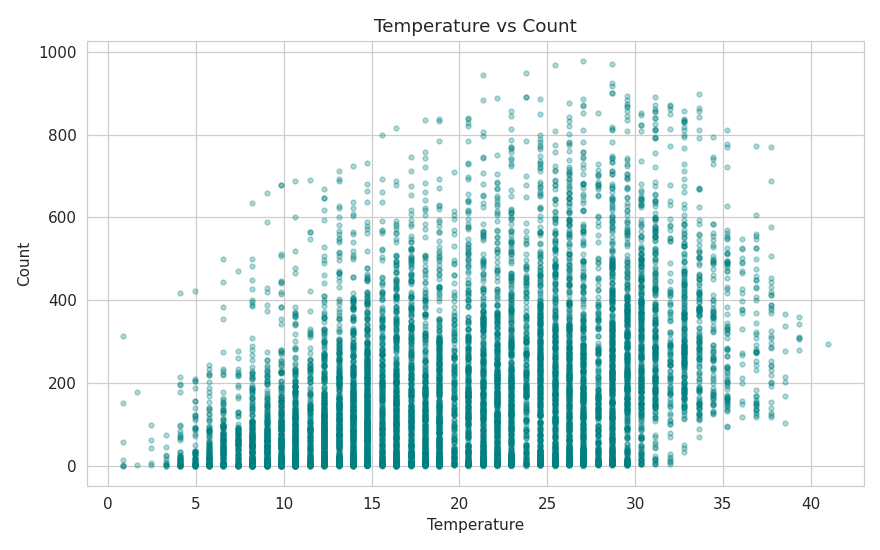

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df['temp'], df['count'], alpha=0.3, s=10, color='teal')
plt.title('Temperature vs Count')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

Observation: count goes up as temp goes up which makes sense (people bike
more when its warm), but it kind of flattens near the top, maybe too hot to bike
comfortably after some point. not a perfectly straight line relationship.

### Plot 3 - count by hour of day (this is the target variable plot)

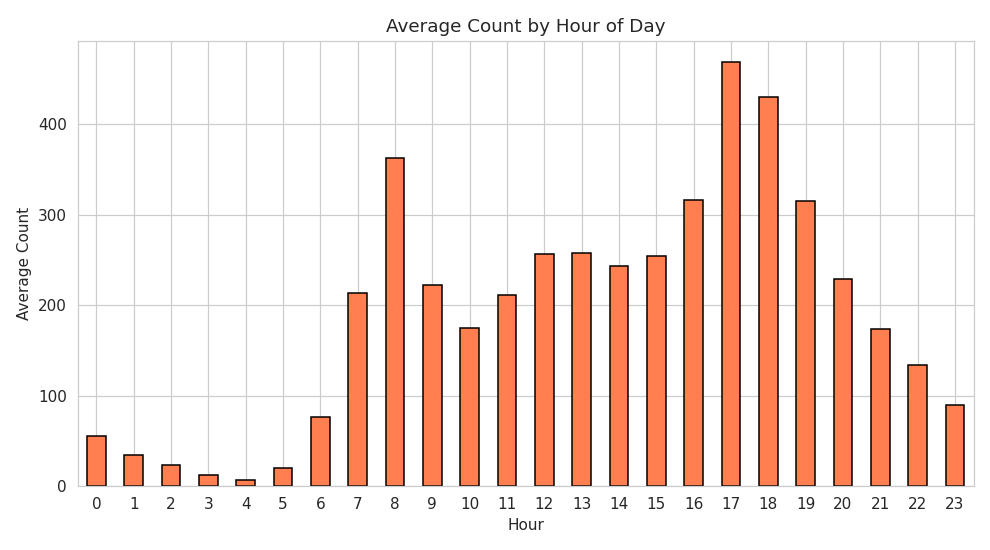

In [15]:
df['hour'] = df['datetime'].dt.hour
hourly_avg = df.groupby('hour')['count'].mean()

plt.figure(figsize=(9,5))
hourly_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Count by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.show()

Observation: this is probably the most useful graph out of all of them.
theres 2 clear spikes, one around 8am and a bigger one around 5-6pm (highest avg is
at hour 17, ~469), matches commute times basically. overnight (like 4am) its almost
nothing. so hour is probably gonna be the single most important feature.

### bonus - correlation heatmap (not required but wanted to check this)

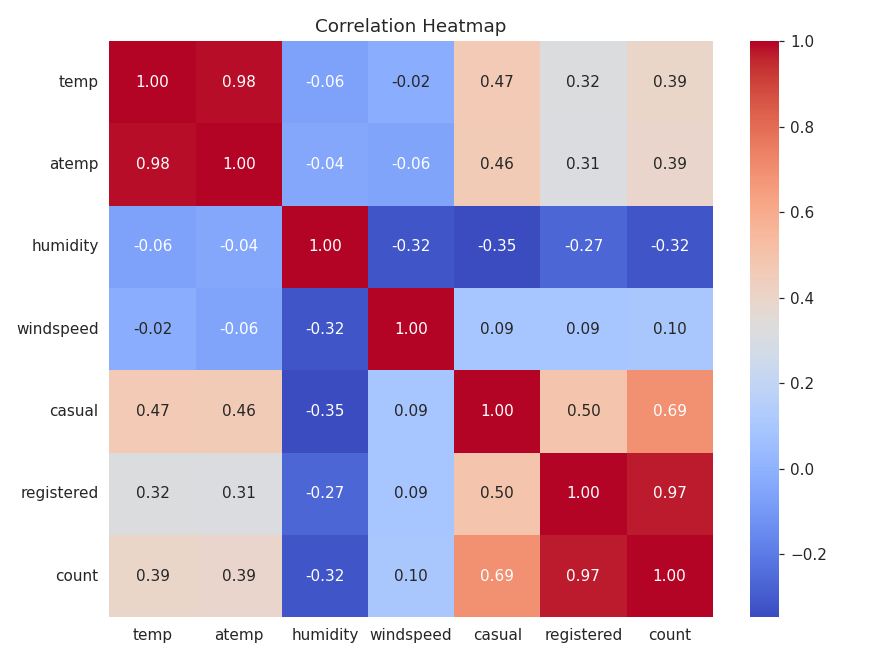

In [16]:
corr = df[['temp','atemp','humidity','windspeed','casual','registered','count']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Observation: temp and atemp are almost the exact same thing (0.98 correlation),
makes sense since atemp is "feels like" temp. so no point keeping both, gonna drop
atemp later. humidity has a mild negative correlation with count, windspeed doesnt
really correlate with anything much.

## 8. Preprocessing

### pulling more stuff out of datetime

In [17]:
df_model = df.copy()
df_model['month'] = df_model['datetime'].dt.month
df_model['dayofweek'] = df_model['datetime'].dt.dayofweek
df_model['year'] = df_model['datetime'].dt.year
# hour already made above

df_model[['datetime','year','month','dayofweek','hour']].head()

            datetime  year  month  dayofweek  hour
0 2011-01-01 00:00:00  2011      1          5     0
1 2011-01-01 01:00:00  2011      1          5     1
2 2011-01-01 02:00:00  2011      1          5     2
3 2011-01-01 03:00:00  2011      1          5     3
4 2011-01-01 04:00:00  2011      1          5     4

### one hot encoding + dropping columns I dont need

In [18]:
df_model = pd.get_dummies(df_model, columns=['season','weather'], drop_first=True)
df_model = df_model.drop(columns=['datetime','casual','registered','atemp'])

print(list(df_model.columns))

['holiday', 'workingday', 'temp', 'humidity', 'windspeed', 'count', 'hour', 'month', 'dayofweek', 'year', 'season_2', 'season_3', 'season_4', 'weather_2', 'weather_3', 'weather_4']

dropped datetime (raw form not usable), casual/registered (would be cheating,
explained above), and atemp (basically same as temp, saw that in the heatmap).
one hot encoded season and weather so the model doesnt think "season 4" is bigger
than "season 1" or anything like that.

### making X and y

In [19]:
X = df_model.drop(columns=['count'])
y = df_model['count']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (10886, 15)
y shape: (10886,)

### train test split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('train:', X_train.shape[0], 'test:', X_test.shape[0])

train: 8708 test: 2178

### scaling

only fitting the scaler on the train data (not test), otherwise info from
the test set leaks into training which messed up one of my earlier mini-projects.
tree models (decision tree/random forest) dont really need scaling but logistic
regression and knn do since they use distance/gradients.

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('scaling done')

scaling done

## 9. Models

### Model A - Linear Regression (predicting count)

In [22]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print('MAE:', mae_lin)
print('MSE:', mse_lin)
print('R2:', r2_lin)

MAE: 105.08956595122476
MSE: 19785.555868000174
R2: 0.4005636891318186

In [23]:
compare_lin = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred_lin[:10].round(1)})
compare_lin

   Actual  Predicted
0     127      229.5
1      13       28.0
2     163      196.9
3     233      280.4
4     222      398.9
5     166      316.6
6     144      196.3
7     376      286.7
8     601      182.1
9      53       31.1

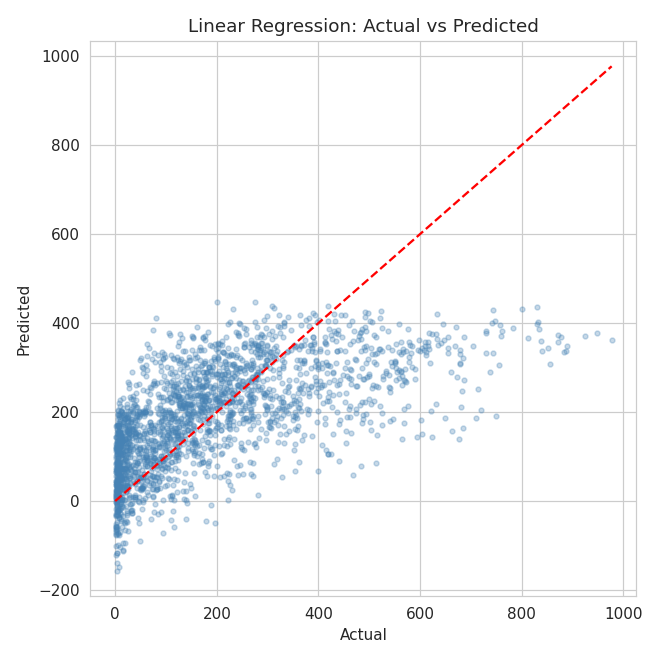

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.3, s=10, color='steelblue')
lims = [0, max(y_test.max(), y_pred_lin.max())]
plt.plot(lims, lims, 'r--')
plt.title('Linear Regression - Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

Conclusion: R2 isnt great (~0.4), and looking at the table above row 8 (actual
601) got predicted as only 182 which is way off. Linear regression is probably too
simple for this, it cant really capture the hour spikes we saw earlier since thats
not a straight line relationship.

### Model B - Logistic Regression (predicting high/low demand)

logistic regression needs a category to predict, but count is a plain number.
so making a new column called high_demand - 1 if the hour's count is above the
median (of train set only, to avoid leakage), else 0.

In [25]:
median_train = y_train.median()
y_train_clf = (y_train > median_train).astype(int)
y_test_clf = (y_test > median_train).astype(int)

print('median used:', median_train)
print(y_train_clf.value_counts())

median used: 145.0
count
0    4359
1    4349
Name: count, dtype: int64

In [26]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_scaled)

acc_log = accuracy_score(y_test_clf, y_pred_log)
cm_log = confusion_matrix(y_test_clf, y_pred_log)

print('Accuracy:', acc_log)
print(cm_log)

Accuracy: 0.7956841138659321
[[882 211]
 [234 851]]

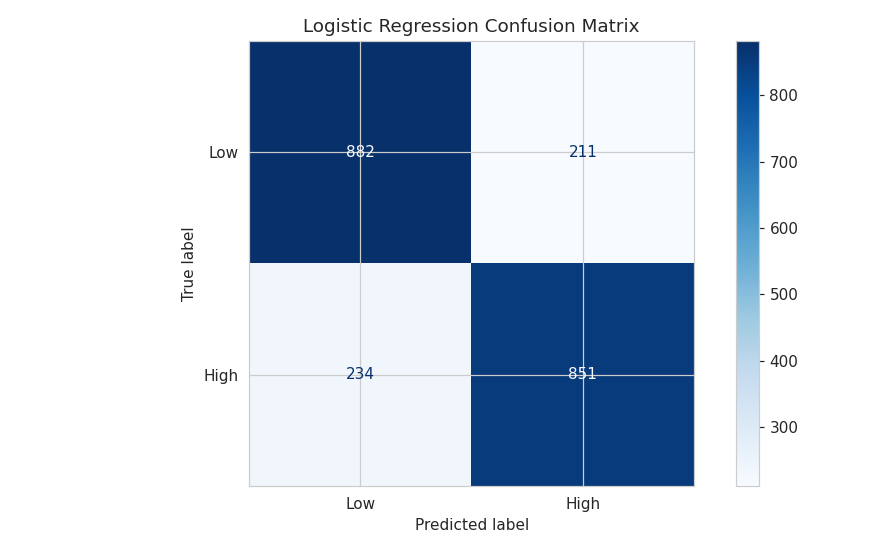

In [27]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Low demand','High demand'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Interpretation: about 80% accuracy, the 2 diagonal boxes (882 and 851) are
correct guesses, the other 2 boxes are where it mixed up high/low. makes sense this
is higher than the R2 from linear regression, guessing high-or-low is a much
simpler question than guessing the actual number.

### Model C - Decision Tree

using DecisionTreeRegressor here since count is a number, not the classifier version.

In [28]:
dt_reg = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print('MAE:', mae_dt)
print('R2:', r2_dt)

MAE: 45.48326899783376
R2: 0.8483589613605871

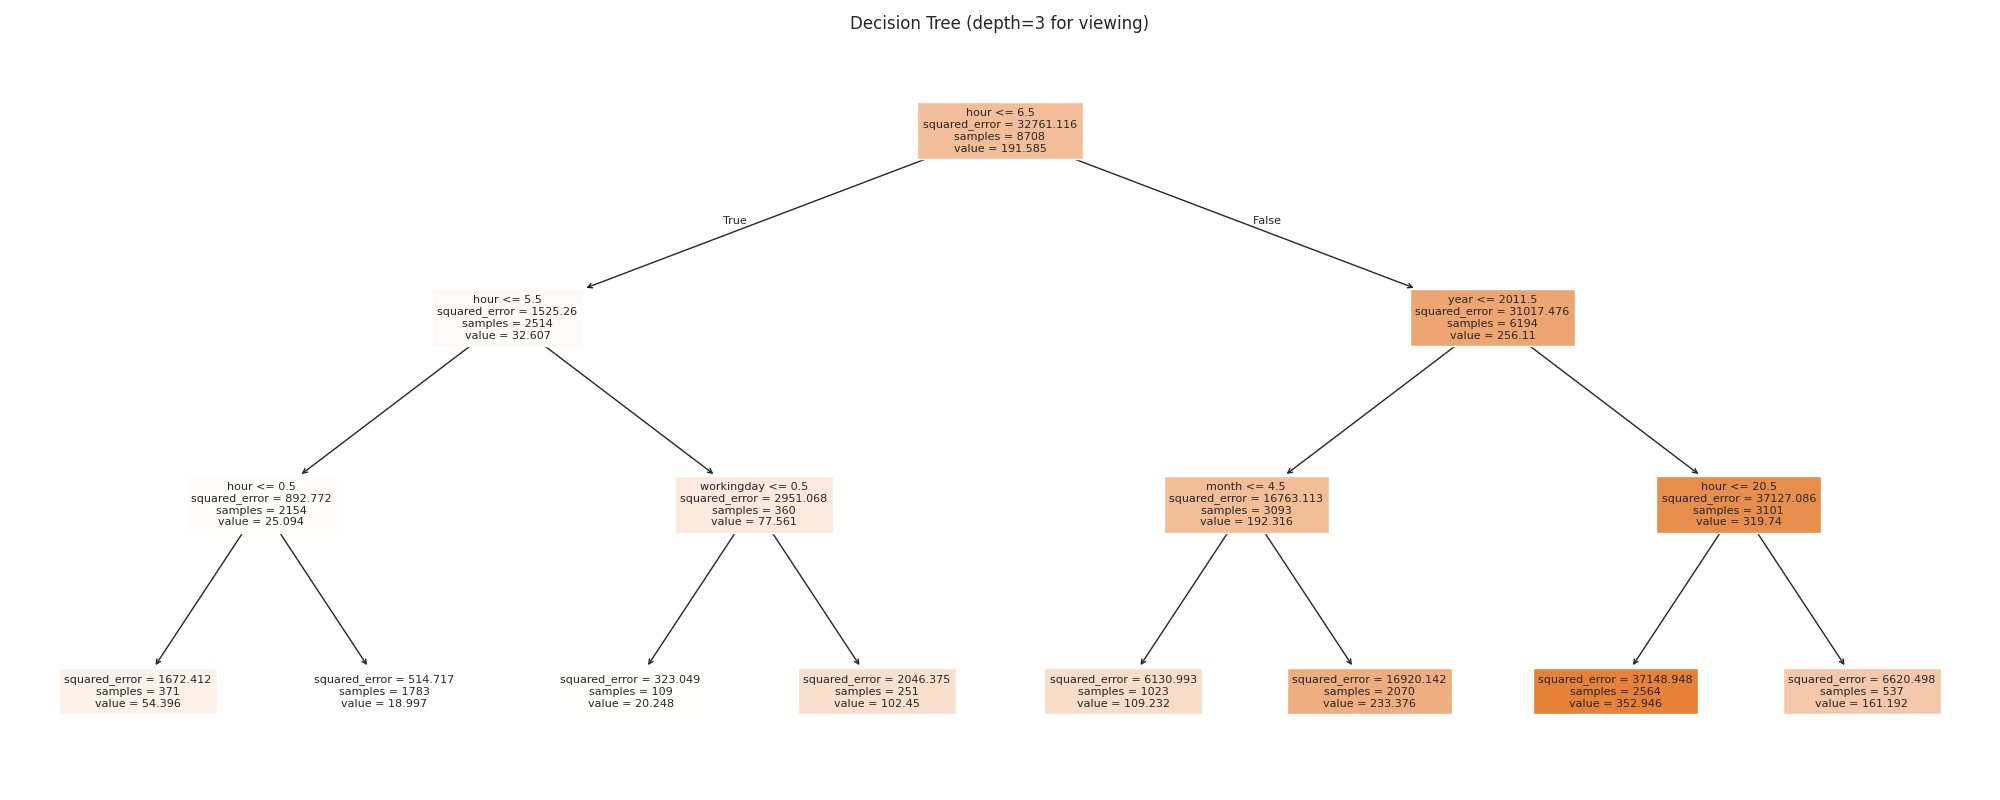

In [29]:
dt_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(20,8))
plot_tree(dt_viz, feature_names=list(X.columns), filled=True, fontsize=8)
plt.title('Decision Tree (depth 3 just so it fits on screen)')
plt.show()

Observation: R2 jumped up a LOT compared to linear regression (0.4 -> 0.85).
the very first split is on hour which matches what the hour graph showed earlier -
its clearly the biggest factor. makes sense a tree does better here since it can
handle those sharp jumps that a straight line just cant.

### Model D - Random Forest

In [30]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('MAE:', mae_rf)
print('R2:', r2_rf)

MAE: 24.526782489396126
R2: 0.953392007859725

top 3 important features:
hour    0.598345
year    0.085982
temp    0.058004
dtype: float64

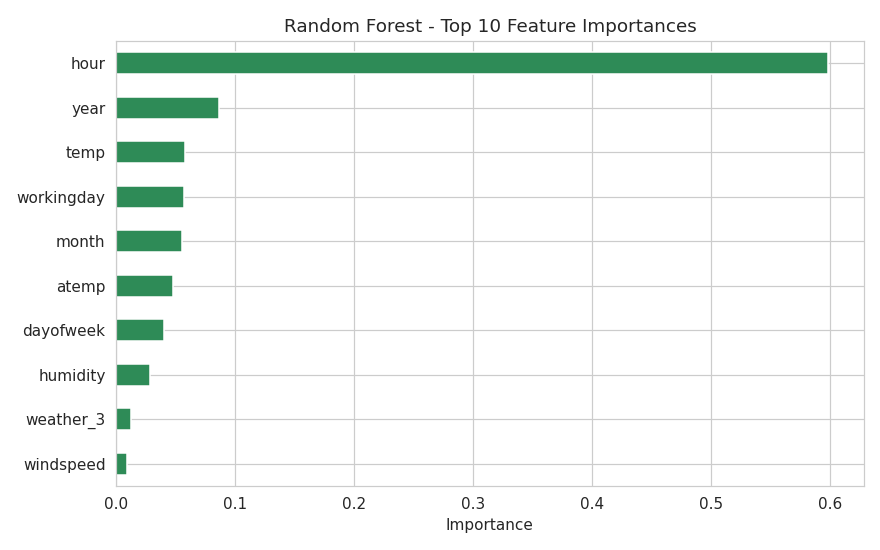

In [31]:
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print('top 3 important features:')
print(importances.head(3))

plt.figure(figsize=(8,5))
importances.head(10).sort_values().plot(kind='barh', color='seagreen')
plt.title('Random Forest Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()

Conclusion: best R2 out of everything so far (0.95!), better than the single
decision tree too. guess thats cause its basically a bunch of trees averaged
together so it doesnt overfit as much as just one tree. hour is again the top
feature by a lot, same as decision tree.

### Model E - KNN

for KNN, scaling matters a lot since it uses distance between points. using
the scaled features from step 8.

In [32]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print('K=5 -> MAE:', mae_knn, 'R2:', r2_knn)

K=5 -> MAE: 74.63425160697888 R2: 0.6178074447055638

now trying a bunch of different k values to see which works best

In [33]:
k_values = [3, 5, 7, 9, 15, 25]
k_results = []

for k in k_values:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    k_results.append({'K': k, 'MAE': round(mean_absolute_error(y_test, pred),2), 'R2': round(r2_score(y_test, pred),4)})

k_results_df = pd.DataFrame(k_results)
k_results_df

   K    MAE      R2
0  3  71.19  0.6323
1  5  74.63  0.6178
2  7  76.75  0.6140
3  9  78.96  0.6002
4  15  84.01  0.5744
5  25  89.49  0.5388

best k: 3

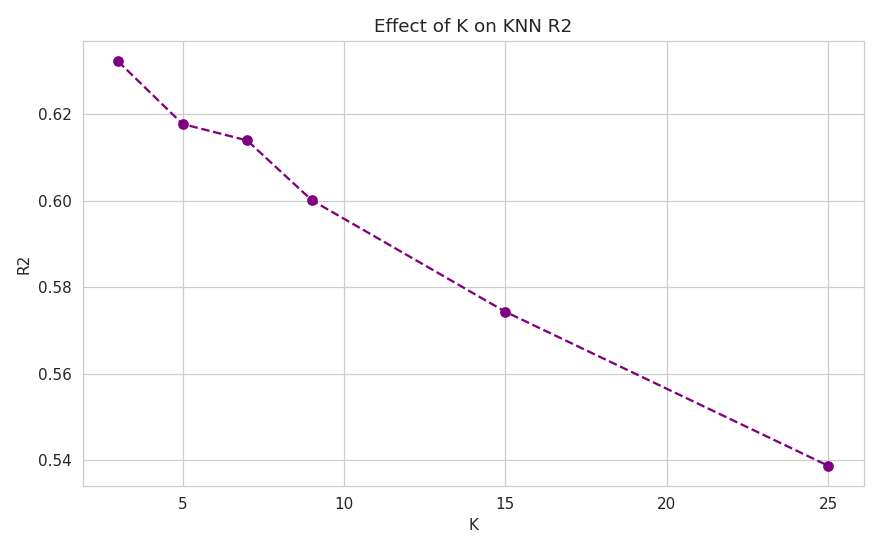

In [34]:
best_row = k_results_df.loc[k_results_df['R2'].idxmax()]
best_k = int(best_row['K'])
print('best k:', best_k)

plt.figure(figsize=(8,5))
plt.plot(k_results_df['K'], k_results_df['R2'], marker='o', linestyle='--', color='purple')
plt.title('Effect of K on KNN R2')
plt.xlabel('K')
plt.ylabel('R2')
plt.show()

Conclusion: smaller k actually did better here, R2 kept dropping as k went up.
i think this is cause a bigger k averages over more neighbors which smooths out the
sharp hour-to-hour changes that matter a lot in this data. so smaller k works
better here (though prob not too small or itd overfit to noise).

## 10. Comparing all models

In [35]:
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_test_scaled)
mae_knn_best = mean_absolute_error(y_test, y_pred_knn_best)
r2_knn_best = r2_score(y_test, y_pred_knn_best)

comparison = pd.DataFrame([
    {'Model': 'Linear Regression', 'Type': 'Regression', 'Metric': 'R2', 'Score': round(r2_lin,4), 'MAE': round(mae_lin,2)},
    {'Model': 'Decision Tree', 'Type': 'Regression', 'Metric': 'R2', 'Score': round(r2_dt,4), 'MAE': round(mae_dt,2)},
    {'Model': 'Random Forest', 'Type': 'Regression', 'Metric': 'R2', 'Score': round(r2_rf,4), 'MAE': round(mae_rf,2)},
    {'Model': f'KNN (k={best_k})', 'Type': 'Regression', 'Metric': 'R2', 'Score': round(r2_knn_best,4), 'MAE': round(mae_knn_best,2)},
    {'Model': 'Logistic Regression', 'Type': 'Classification', 'Metric': 'Accuracy', 'Score': round(acc_log,4), 'MAE': '-'},
]).sort_values(by='Score', ascending=False).reset_index(drop=True)

comparison

                Model            Type    Metric  Score     MAE
0        Random Forest      Regression        R2  0.9534   24.53
1        Decision Tree      Regression        R2  0.8484   45.48
2  Logistic Regression  Classification  Accuracy  0.7957       -
3            KNN (k=3)      Regression        R2  0.6323   71.19
4    Linear Regression      Regression        R2  0.4006  105.09

So we have 3 regression models (R2) and 2 classification-ish results
(accuracy) - not exactly the same scale but both go 0 to 1, higher = better, so
still roughly comparable side by side.

Best regression model: Random Forest, clearly the highest R2 (0.95) and lowest
error (MAE 24.5).
Worst regression model: Linear Regression, R2 only 0.4, probably cause it assumes
a straight line and this data has curves/jumps (like the hour spikes) that a
straight line just cant follow.
Logistic Regression isnt really comparable to the other 3 since its solving an
easier problem (just high/low instead of the exact number), only including it
since the task wants all 5 models trained.

My pick: Random Forest. best score, doesnt need scaling, and it also tells you
which feature mattered most (hour) instead of just spitting out a number.

## End note

thats my full workflow - loaded the data, explored it, didnt find any missing
values or dupes but did drop atemp/casual/registered since they were basically
useless or cheating, made 4 graphs (3 required + 1 bonus heatmap), did all the
preprocessing (datetime features, one hot encoding, scaling), trained all 5
required models and compared them at the end. Random Forest came out clearly on
top for this dataset.